# <span style="color:#2F749F;"><strong> Sesión práctica 3: Codificación y transformación de variables</strong></span>
---
<p align="right">
  <a href="https://colab.research.google.com/github/mariabda2/intro_data_2026/blob/main/sesiones_practicas/sp_3_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>

## <span style="color:black;"><strong>Datos del estudiante</strong></span>


*   Jose Camilo Loaiza Hoyos

*   Sarai Restrepo Rodríguez







## <span style="color:#2F749F;"><strong>Ejercicio 1: Comparación de métodos de escalamiento</strong></span>

A partir de un conjunto de datos real sobre **vinos**, analiza cómo cambia la escala de las variables al aplicar diferentes métodos de **escalamiento de datos**, y compara visualmente sus efectos sobre la distribución.

1. Carga el conjunto de datos **wine** desde la librería `sklearn.datasets` usando `load_wine()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo):
   - `alcohol`
   - `malic_acid`
   - `color_intensity`

4. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - `StandardScaler`
   - `MinMaxScaler`
   - `RobustScaler`
   - `Z-Score`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **StandardScaler**
   - Distribución con **MinMaxScaler**
   - Distribución con **RobustScaler**
   - Distribución con **Z-Score**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from scipy.stats import zscore

In [32]:

#Punto 1
wine = load_wine()

#Punto 2
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
print("Las variables disponibles en el dataset son:")
print(df_wine.columns.tolist())


Las variables disponibles en el dataset son:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [ ]:
#Punto 3
columnas= ['alcohol', 'malic_acid', 'magnesium']
df_seleccion = df_wine[columnas].copy()

print("Datos originales seleccionados (primeras 3 filas):")
print(df_seleccion.head(3))

Datos originales seleccionados (primeras 3 filas):
   alcohol  malic_acid  color_intensity
0    14.23        1.71             5.64
1    13.20        1.78             4.38
2    13.16        2.36             5.68


In [34]:
# Inicializar los escaladores de scikit-learn
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

# Aplicar StandardScaler
df_standard = pd.DataFrame(
    standard_scaler.fit_transform(df_seleccion),
    columns=columnas_seleccionadas
)

# Aplicar MinMaxScaler
df_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(df_seleccion),
    columns=columnas_seleccionadas
)

# Aplicar RobustScaler
df_robust = pd.DataFrame(
    robust_scaler.fit_transform(df_seleccion),
    columns=columnas_seleccionadas
)


# Aplicar Z-Score
df_zscore = df_seleccion.apply(zscore)

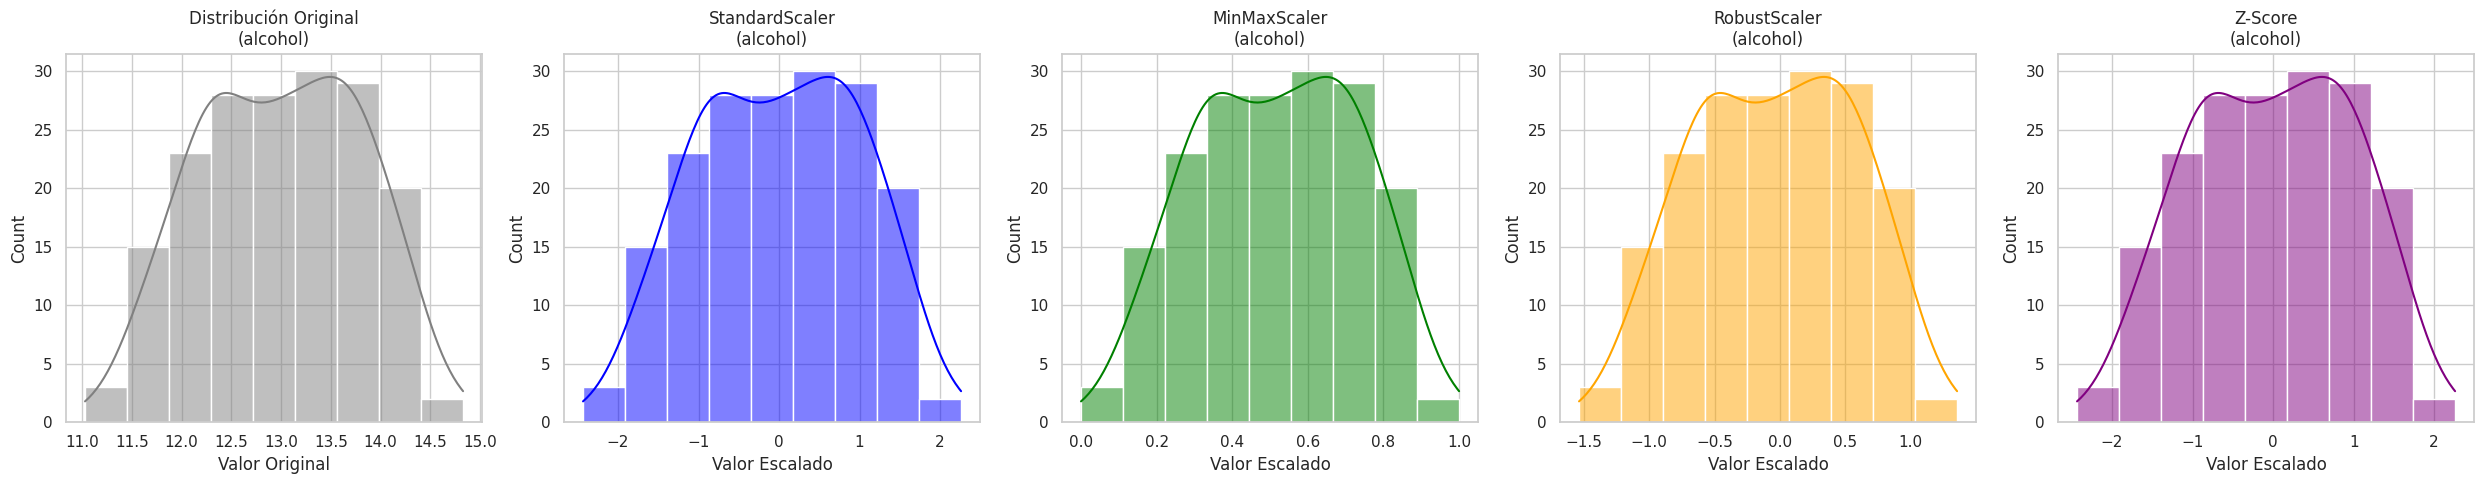

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# variable para comparar
variable = 'alcohol'

# Crear 5 subgráficos
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
sns.set_theme(style="whitegrid")

# 1. Distribución Original
sns.histplot(df_seleccion[variable], kde=True, ax=axes[0], color='gray')
axes[0].set_title(f'Distribución Original\n({variable})')
axes[0].set_xlabel('Valor Original')

# 2. Distribución con StandardScaler
sns.histplot(df_standard[variable], kde=True, ax=axes[1], color='blue')
axes[1].set_title(f'StandardScaler\n({variable})')
axes[1].set_xlabel('Valor Escalado')

# 3. Distribución con MinMaxScaler
sns.histplot(df_minmax[variable], kde=True, ax=axes[2], color='green')
axes[2].set_title(f'MinMaxScaler\n({variable})')
axes[2].set_xlabel('Valor Escalado')

# 4. Distribución con RobustScaler
sns.histplot(df_robust[variable], kde=True, ax=axes[3], color='orange')
axes[3].set_title(f'RobustScaler\n({variable})')
axes[3].set_xlabel('Valor Escalado')

# 5. Distribución con Z-Score
sns.histplot(df_zscore[variable], kde=True, ax=axes[4], color='purple')
axes[4].set_title(f'Z-Score\n({variable})')
axes[4].set_xlabel('Valor Escalado')

# Ajustar el espaciado para que no se superpongan los textos
plt.tight_layout()

plt.show()

## <span style="color:#2F749F;"><strong>Ejercicio 2: Comparación de escalamiento RobustScaler vs Z-Score</strong></span>

A partir de un conjunto de datos real sobre **diabetes**, analiza cómo cambia la escala de las variables al aplicar **estandarización con Z-Score** y **escalamiento robusto**, y compara visualmente sus efectos cuando existen **posibles valores atípicos**.

1. Carga el conjunto de datos **diabetes** desde la librería `sklearn.datasets` usando `load_diabetes()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo: `bmi`, `bp`, `s5` u otras disponibles en el dataset).

4. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - **StandardScaler** (Z-Score).
   - **RobustScaler** (basado en mediana e IQR).

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución **escalada con Z-Score**
   - Distribución **escalada con RobustScaler**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [36]:
diabetes = load_diabetes()

df_diabetes = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
print("Las variables disponibles en el dataset de diabetes son:")
print(df_diabetes.columns.tolist())



Las variables disponibles en el dataset de diabetes son:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [37]:
columnas_seleccionadas_diab = ['bmi', 'bp', 's5']
df_seleccion_diab = df_diabetes[columnas_seleccionadas_diab].copy()
print(df_seleccion_diab.head(3))

        bmi        bp        s5
0  0.061696  0.021872  0.019907
1 -0.051474 -0.026328 -0.068332
2  0.044451 -0.005670  0.002861


In [38]:
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()


# Aplicar StandardScaler
df_standard_diab = pd.DataFrame(
    standard_scaler.fit_transform(df_seleccion_diab),
    columns=columnas_seleccionadas_diab
)

# Aplicar RobustScaler
df_robust_diab = pd.DataFrame(
    robust_scaler.fit_transform(df_seleccion_diab),
    columns=columnas_seleccionadas_diab
)

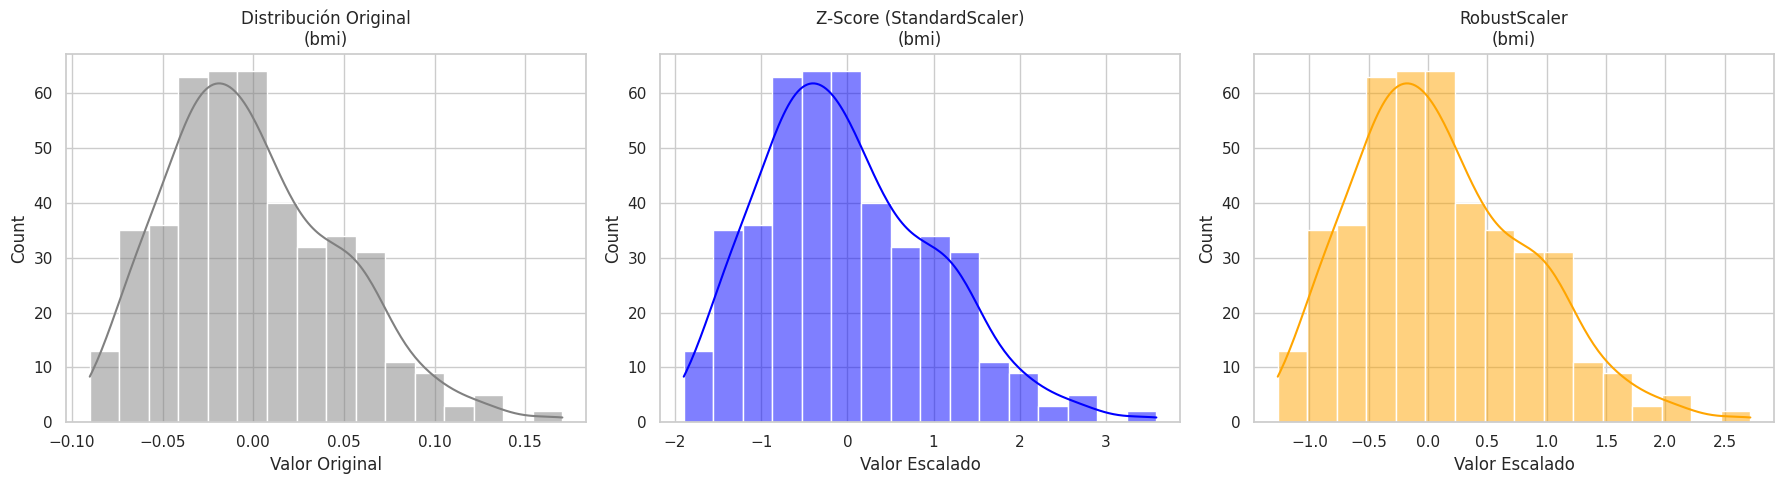

In [39]:
# variable elegida
variable_diab = 'bmi'

# figura con 3 subgráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_theme(style="whitegrid")

# 1. Distribución Original
sns.histplot(df_seleccion_diab[variable_diab], kde=True, ax=axes[0], color='gray')
axes[0].set_title(f'Distribución Original\n({variable_diab})')
axes[0].set_xlabel('Valor Original')

# 2. Distribución con Z-Score (StandardScaler)
sns.histplot(df_standard_diab[variable_diab], kde=True, ax=axes[1], color='blue')
axes[1].set_title(f'Z-Score (StandardScaler)\n({variable_diab})')
axes[1].set_xlabel('Valor Escalado')

# 3. Distribución con RobustScaler
sns.histplot(df_robust_diab[variable_diab], kde=True, ax=axes[2], color='orange')
axes[2].set_title(f'RobustScaler\n({variable_diab})')
axes[2].set_xlabel('Valor Escalado')

# Ajustar el espaciado para evitar que los textos se superpongan
plt.tight_layout()

plt.show()

## <span style="color:#2F749F;"><strong>Ejercicio 3: Comparación de normalización L1 y L2</strong></span>

A partir de un conjunto de datos real sobre **precios de viviendas**, analiza cómo cambian los valores de las variables al aplicar **normalización L1 y L2**, y compara visualmente sus efectos sobre la distribución de los datos.

1. Carga el conjunto de datos **California Housing** desde la librería `sklearn.datasets` usando `fetch_california_housing()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo):
   - `MedInc`
   - `AveRooms`
   - `HouseAge`

4. Aplica los siguientes métodos de **normalización** sobre las variables seleccionadas utilizando `Normalizer` de `sklearn.preprocessing`:
   - **Normalización L1**
   - **Normalización L2**

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **normalización L1**
   - Distribución con **normalización L2**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

## <span style="color:#2F749F;"><strong>Ejercicio 4: Comparación de transformaciones para reducir asimetría</strong></span>

A partir de un conjunto de datos real sobre **pacientes con diabetes**, analiza cómo cambian las distribuciones de algunas variables clínicas al aplicar diferentes **transformaciones matemáticas utilizadas para reducir la asimetría (skewness) o estabilizar la varianza**.

1. Carga el conjunto de datos **diabetes** desde la librería `sklearn.datasets` usando `load_diabetes()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **dos variables numéricas** para el análisis (por ejemplo: `bmi`, `bp` o `s5`).

4. Aplica las siguientes **transformaciones** sobre una de las variables seleccionadas:

   - **Transformación logarítmica** usando `np.log()` o `np.log1p()`
   - **Transformación logarítmica reflejada** (útil cuando existe asimetría negativa)
   - **Transformación cuadrática** usando `x²`
   - **Transformación Box-Cox** usando `scipy.stats.boxcox`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de la variable en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **transformación log**
   - Distribución con **log reflejado**
   - Distribución con **transformación cuadrática**
   - Distribución con **transformación Box-Cox**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

## <span style="color:#2F749F;"><strong>Ejercicio 5: Comparación de transformaciones para reducir asimetría</strong></span>

A partir de un conjunto de datos real sobre **pacientes con enfermedades cardíacas**, analiza cómo cambian las distribuciones de algunas variables clínicas al aplicar diferentes **transformaciones matemáticas utilizadas para reducir la asimetría (skewness) o estabilizar la varianza**.

1. Carga el conjunto de datos **Heart Disease** desde la librería `seaborn` usando `load_dataset("heart")`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **dos variables numéricas** para el análisis (por ejemplo:  
   - `chol` (colesterol)  
   - `trestbps` (presión arterial en reposo)  
   - `thalach` (frecuencia cardíaca máxima)).

4. Aplica las siguientes **transformaciones** sobre una de las variables seleccionadas:

   - **Raíz cuadrada** usando `np.sqrt()`  
   - **Recíproca** usando `1/x`  
   - **Transformación Yeo-Johnson** usando `PowerTransformer(method="yeo-johnson")`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de la variable en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **transformación raíz cuadrada**
   - Distribución con **transformación recíproca**
   - Distribución con **transformación Yeo-Johnson**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.